In [ ]:
# Cell 1: Import libraries

import pandas as pd
import numpy as np
import random
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [ ]:
# Cell 2: Define student behavior categories

motivated = [
    "I will complete my assignment today",
    "Let me start studying early",
    "I want to improve my grades",
    "Consistency is key to success",
    "I will practice coding daily"
]

procrastinator = [
    "I will do it tomorrow",
    "Let me watch one more episode",
    "I still have time",
    "I'll start after some time",
    "Deadline is far away"
]

stressed = [
    "Too many assignments to complete",
    "I am feeling overwhelmed",
    "Exams are giving me anxiety",
    "I don't think I can finish everything",
    "So much pressure from studies"
]

confident = [
    "I am well prepared for exams",
    "I can solve this easily",
    "I have practiced enough",
    "This subject is easy for me",
    "I am confident about my performance"
]

In [ ]:
# Cell 3: Store categories in dictionary

categories = {
    "motivated": motivated,
    "procrastinator": procrastinator,
    "stressed": stressed,
    "confident": confident
}

In [ ]:
# Cell 4: Generate dataset

data = {"text": [], "label": []}

random.seed(101)
np.random.seed(101)

for _ in range(50):  # Increase for bigger dataset
    for label, phrases in categories.items():
        data["text"].append(random.choice(phrases))
        data["label"].append(label)

df = pd.DataFrame(data)

print("Dataset size:", df.shape)
df.head()

Dataset size: (200, 2)


,text,label
0,I will practice coding daily,motivated
1,Let me watch one more episode,procrastinator
2,So much pressure from studies,stressed
3,I have practiced enough,confident
4,Consistency is key to success,motivated


In [ ]:
# Cell 5: Add realistic noise

overlap_phrases = [
    " but I am not sure",
    " maybe I will change my plan",
    " depends on the situation",
    " I am still thinking",
    " not fully confident though"
]

def add_noise(row):
    text = row["text"] + random.choice(overlap_phrases)

    # Add contradiction (20%)
    if random.random() < 0.2:
        other_label = random.choice(list(categories.keys()))
        text += " however " + random.choice(categories[other_label]).lower()

    return text

df["text"] = df.apply(add_noise, axis=1)

df.head()

,text,label
0,I will practice coding daily but I am not sure,motivated
1,Let me watch one more episode depends on the s...,procrastinator
2,So much pressure from studies but I am not sure,stressed
3,I have practiced enough not fully confident th...,confident
4,Consistency is key to success depends on the s...,motivated


In [ ]:
# Cell 6: Preprocessing

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)   # remove punctuation
    return text

df["clean_text"] = df["text"].apply(preprocess)

df[["text", "clean_text"]].head()

,text,clean_text
0,I will practice coding daily but I am not sure,i will practice coding daily but i am not sure
1,Let me watch one more episode depends on the s...,let me watch one more episode depends on the s...
2,So much pressure from studies but I am not sure,so much pressure from studies but i am not sure
3,I have practiced enough not fully confident th...,i have practiced enough not fully confident th...
4,Consistency is key to success depends on the s...,consistency is key to success depends on the s...


In [ ]:
# Cell 7: Feature extraction

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=500)

X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

print("Feature shape:", X.shape)

Feature shape: (200, 269)


In [ ]:
# Cell 8: Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (160, 269)
Test size: (40, 269)


In [ ]:
# Cell 9: Models

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC(kernel="linear", C=0.8),
    "Decision Tree": DecisionTreeClassifier()
}

In [ ]:
# Cell 10: Training and evaluation

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))


Naive Bayes
Accuracy: 0.95
                precision    recall  f1-score   support

     confident       0.88      1.00      0.93         7
     motivated       1.00      0.85      0.92        13
procrastinator       0.90      1.00      0.95         9
      stressed       1.00      1.00      1.00        11

      accuracy                           0.95        40
     macro avg       0.94      0.96      0.95        40
  weighted avg       0.96      0.95      0.95        40


Logistic Regression
Accuracy: 0.95
                precision    recall  f1-score   support

     confident       1.00      0.86      0.92         7
     motivated       0.92      0.92      0.92        13
procrastinator       0.90      1.00      0.95         9
      stressed       1.00      1.00      1.00        11

      accuracy                           0.95        40
     macro avg       0.96      0.95      0.95        40
  weighted avg       0.95      0.95      0.95        40


SVM
Accuracy: 0.95
              

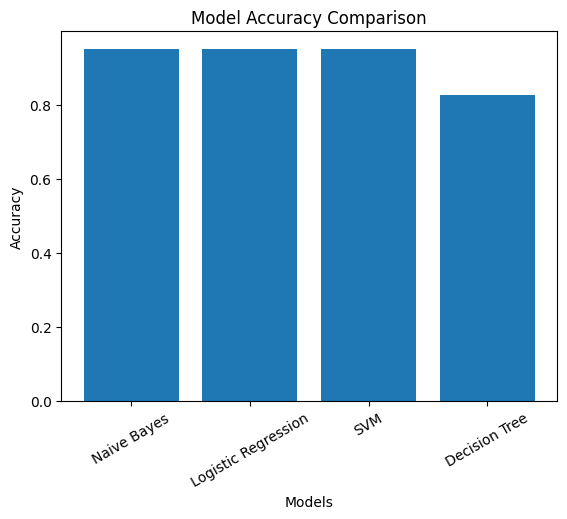

In [ ]:
# Cell 11: Accuracy comparison

names = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(names, scores)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Cell 12: Select best model

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Naive Bayes


In [ ]:
# Cell 13: Confusion Matrix

preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 7  0  0  0]
 [ 1 11  1  0]
 [ 0  0  9  0]
 [ 0  0  0 11]]


In [ ]:
# Cell 14: Final classification report

print("Final Report for Best Model:\n")
print(classification_report(y_test, preds))

Final Report for Best Model:

                precision    recall  f1-score   support

     confident       0.88      1.00      0.93         7
     motivated       1.00      0.85      0.92        13
procrastinator       0.90      1.00      0.95         9
      stressed       1.00      1.00      1.00        11

      accuracy                           0.95        40
     macro avg       0.94      0.96      0.95        40
  weighted avg       0.96      0.95      0.95        40



In [ ]:
# Cell 15: Prediction function

def predict_behavior(text):
    text = preprocess(text)
    vector = vectorizer.transform([text])
    prediction = best_model.predict(vector)
    return prediction[0]

In [ ]:
# Cell 16: Try your own inputs

test_sentences = [
    "I will study today and complete everything",
    "I will do it later",
    "I am very stressed about exams",
    "I am fully prepared and confident"
]

for sentence in test_sentences:
    print(f"\nInput: {sentence}")
    print("Prediction:", predict_behavior(sentence))


Input: I will study today and complete everything
Prediction: motivated

Input: I will do it later
Prediction: procrastinator

Input: I am very stressed about exams
Prediction: confident

Input: I am fully prepared and confident
Prediction: confident


In [ ]:
# Cell 17: Save model

import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model saved successfully")

Model saved successfully


**Conclusion**

In [ ]:
# In this project, multiple machine learning models were applied for student behavior classification using TF-IDF features. Naive Bayes, Logistic Regression, and SVM achieved high accuracy (95%), while Decision Tree performed lower. Among them, Naive Bayes was selected as the best model due to its consistent performance. This shows that probabilistic and linear models work effectively for text-based classification tasks.